# Gaudin Selectivity Index 예측

**전략**: Silica_DOE + Fe_DOE 두 모델의 예측값을 조합 → Gaudin SI 계산

$$SI = \frac{\% Fe_{concentrate} \times \% Silica_{feed}}{\% Silica_{concentrate} \times \% Fe_{feed}}$$

| 단계 | 내용 |
|------|------|
| Step 0 | 데이터 로드 |
| Step 1 | RSM 집계 변수 생성 (두 모델 공통) |
| Step 2 | Lag 피처 추가 + Train/Test 분할 |
| Step 3 | 피처셋 정의 (각 DOE 실험 B 기준) |
| Step 4 | Si / Fe XGBoost 모델 학습 |
| Step 5 | Gaudin SI 계산 (2단계 조합) |
| Step 6 | SI 직접 예측 베이스라인 |
| Step 7 | 성능 비교 + 시각화 |
| Step 8 | 상대 RMSE — RMSE > 1의 해석 |
| Step 9 | 최적 조업 조건 탐색 (scipy.optimize) |

> ⚠ % Silica Concentrate는 CSV에 **log 변환된 값** → Gaudin SI 계산 시 `exp()` 역변환 필수

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

_candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR"]
_available  = {f.name for f in fm.fontManager.ttflist}
_font       = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100

In [2]:
# ── Step 0. 데이터 로드 ────────────────────────────────────────────────────────
df_raw = pd.read_csv("Silica_model_ready.csv", parse_dates=["date"], index_col="date")

X_COLS = [
    "% Iron Feed", "% Silica Feed",
    "Starch Flow", "Amina Flow", "Ore Pulp Flow", "Ore Pulp pH", "Ore Pulp Density",
    "Flotation Column 01 Air Flow", "Flotation Column 02 Air Flow",
    "Flotation Column 03 Air Flow", "Flotation Column 04 Air Flow",
    "Flotation Column 05 Air Flow", "Flotation Column 06 Air Flow",
    "Flotation Column 07 Air Flow",
    "Flotation Column 01 Level", "Flotation Column 02 Level",
    "Flotation Column 03 Level", "Flotation Column 04 Level",
    "Flotation Column 05 Level", "Flotation Column 06 Level",
    "Flotation Column 07 Level",
]

TARGET_FE = "% Iron Concentrate"
TARGET_SI = "% Silica Concentrate"  # CSV에 log 변환된 값

df = df_raw[X_COLS + [TARGET_FE, TARGET_SI]].copy()
print(f"데이터 shape: {df.shape}  ({df.index[0].date()} ~ {df.index[-1].date()})")
print(f"결측치: {df.isna().sum().sum()}개")
print()
print("⚠ % Silica Concentrate는 log 변환된 값 — Gaudin SI 계산 시 exp() 필요")
display(df[[TARGET_FE, TARGET_SI]].describe().round(4))

데이터 shape: (4091, 23)  (2017-03-10 ~ 2017-09-09)
결측치: 0개

⚠ % Silica Concentrate는 log 변환된 값 — Gaudin SI 계산 시 exp() 필요


,% Iron Concentrate,% Silica Concentrate
count,4091.0000,4091.0000
mean,65.0476,1.1507
std,1.1168,0.3140
min,62.1350,0.4700
25%,64.3600,0.8920
50%,65.2100,1.0986
75%,65.8600,1.3888
max,68.0100,1.8508


In [3]:
# ── Step 1. RSM 집계 변수 생성 (두 DOE 노트북과 동일) ─────────────────────────
AIR_COLS   = [c for c in X_COLS if "Air Flow" in c]
LEVEL_COLS = [c for c in X_COLS if "Level" in c]

df_rsm = pd.DataFrame(index=df.index)

PROCESS_LABELS = ["P01","P02","P03","P04","P05","P06","P07"]
for col, lbl in zip(X_COLS[:7], PROCESS_LABELS):
    df_rsm[lbl] = df[col]

df_rsm["RA"] = df[AIR_COLS[:3]].mean(axis=1)    # Rougher Air   Col01~03
df_rsm["CA"] = df[AIR_COLS[3:]].mean(axis=1)    # Cleaner Air   Col04~07
df_rsm["RL"] = df[LEVEL_COLS[:3]].mean(axis=1)  # Rougher Level Col01~03
df_rsm["CL"] = df[LEVEL_COLS[3:]].mean(axis=1)  # Cleaner Level Col04~07

print(f"집계 변수 생성 완료: {list(df_rsm.columns)}")

집계 변수 생성 완료: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL']


In [4]:
# ── Step 2. Lag 피처 추가 + Train/Test 분할 ────────────────────────────────────
df["Fe_lag1"]     = df[TARGET_FE].shift(1)
df["Fe_lag2"]     = df[TARGET_FE].shift(2)
df["Silica_lag1"] = df[TARGET_SI].shift(1)
df["Silica_lag2"] = df[TARGET_SI].shift(2)

for col in ["Fe_lag1","Fe_lag2","Silica_lag1","Silica_lag2"]:
    df_rsm[col] = df[col]

# 두 lag 세트 모두 유효한 공통 인덱스
LAG_COLS  = ["Fe_lag1","Fe_lag2","Silica_lag1","Silica_lag2"]
valid_idx = df.dropna(subset=LAG_COLS).index
df_v      = df.loc[valid_idx]
df_rsm_v  = df_rsm.loc[valid_idx]

split = int(len(valid_idx) * 0.7)

y_fe = df_v[TARGET_FE]
y_si = df_v[TARGET_SI]
y_fe_train, y_fe_test = y_fe.iloc[:split], y_fe.iloc[split:]
y_si_train, y_si_test = y_si.iloc[:split], y_si.iloc[split:]

print(f"공통 유효 데이터: {len(valid_idx):,}행")
print(f"Train: {split:,}행 | Test: {len(valid_idx)-split:,}행")

공통 유효 데이터: 4,089행
Train: 2,862행 | Test: 1,227행


In [5]:
# ── Step 3. 피처셋 정의 (두 DOE 실험 B 동일 구성) ────────────────────────────
# Silica_DOE 실험 B: P01~P07 전체 + 집계 4개 (Fe_DOE와 동일)
SI_FEAT_B = ["P01","P02","P03","P04","P05","P06","P07","RA","CA","RL","CL",
             "Silica_lag1","Silica_lag2"]

# Fe_DOE 실험 B: 동일 구성
FE_FEAT_B  = ["P01","P02","P03","P04","P05","P06","P07","RA","CA","RL","CL",
              "Fe_lag1","Fe_lag2"]

X_si_train = df_rsm_v[SI_FEAT_B].iloc[:split]
X_si_test  = df_rsm_v[SI_FEAT_B].iloc[split:]
X_fe_train = df_rsm_v[FE_FEAT_B].iloc[:split]
X_fe_test  = df_rsm_v[FE_FEAT_B].iloc[split:]

print(f"Si 모델 B 피처: {len(SI_FEAT_B)}개  {SI_FEAT_B}")
print(f"Fe 모델 B 피처: {len(FE_FEAT_B)}개  {FE_FEAT_B}")
print("※ 두 모델 공정 변수 동일 — lag만 각자 타겟 기준")

Si 모델 B 피처: 13개  ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL', 'Silica_lag1', 'Silica_lag2']
Fe 모델 B 피처: 13개  ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'RA', 'CA', 'RL', 'CL', 'Fe_lag1', 'Fe_lag2']
※ 두 모델 공정 변수 동일 — lag만 각자 타겟 기준


In [6]:
# ── Step 4. Tuned RF 모델 로드 (Silica_DOE + Fe_DOE 최종 선정 모델) ───────────
import joblib

model_si = joblib.load('si_tuned_rf.pkl')
model_fe = joblib.load('fe_tuned_rf.pkl')

pred_si_log = model_si.predict(X_si_test)
pred_fe     = model_fe.predict(X_fe_test)

si_rmse_ind = np.sqrt(mean_squared_error(y_si_test, pred_si_log))
si_r2_ind   = r2_score(y_si_test, pred_si_log)
fe_rmse_ind = np.sqrt(mean_squared_error(y_fe_test, pred_fe))
fe_r2_ind   = r2_score(y_fe_test, pred_fe)

SEP = "=" * 55
print(SEP)
print("  Tuned RF — 개별 모델 성능 확인")
print(SEP)
print(f"  [Silica]  RMSE: {si_rmse_ind:.4f} | R²: {si_r2_ind:.4f}")
print(f"  [Fe]      RMSE: {fe_rmse_ind:.4f} | R²: {fe_r2_ind:.4f}")


  Tuned RF — 개별 모델 성능 확인
  [Silica]  RMSE: 0.1902 | R²: 0.6229
  [Fe]      RMSE: 0.7245 | R²: 0.5520


In [7]:
# ── Step 5. Gaudin SI 계산 (2단계 조합) ──────────────────────────────────────
# SI = (Fe_conc × Silica_feed) / (Silica_conc × Fe_feed)

fe_feed_test = df_v["% Iron Feed"].iloc[split:].values
si_feed_test = df_v["% Silica Feed"].iloc[split:].values

# 예측 SI
pred_si_pct = np.exp(pred_si_log)                                  # log→% Silica
pred_SI     = (pred_fe * si_feed_test) / (pred_si_pct * fe_feed_test)

# 실제 SI
act_fe  = y_fe_test.values
act_si  = np.exp(y_si_test.values)                                 # log→% Silica
act_SI  = (act_fe  * si_feed_test) / (act_si  * fe_feed_test)

si_rmse = np.sqrt(mean_squared_error(act_SI, pred_SI))
si_r2   = r2_score(act_SI, pred_SI)

print("=" * 55)
print("  Gaudin SI 예측 결과 (2단계 조합)")
print("=" * 55)
print(f"  SI RMSE : {si_rmse:.4f}")
print(f"  SI R²   : {si_r2:.4f}")
print(f"  실제 SI  평균: {act_SI.mean():.4f} ± {act_SI.std():.4f}")
print(f"  예측 SI  평균: {pred_SI.mean():.4f} ± {pred_SI.std():.4f}")

  Gaudin SI 예측 결과 (2단계 조합)
  SI RMSE : 1.4034
  SI R²   : 0.8857
  실제 SI  평균: 6.8147 ± 4.1515
  예측 SI  평균: 6.6928 ± 3.6995


In [8]:
# ── Step 6. SI 직접 예측 베이스라인 (Tuned RF) ───────────────────────────────
# 전체 데이터에서 실제 SI 계산 후 RF로 직접 예측
fe_feed_all = df_v["% Iron Feed"].values
si_feed_all = df_v["% Silica Feed"].values
y_SI_all    = (df_v[TARGET_FE].values * si_feed_all) / (np.exp(df_v[TARGET_SI].values) * fe_feed_all)
y_SI_ser    = pd.Series(y_SI_all, index=valid_idx)
y_SI_train  = y_SI_ser.iloc[:split]
y_SI_test   = y_SI_ser.iloc[split:]

# 두 모델 피처 합집합 (중복 제거, lag 전부 포함)
DIRECT_FEAT = ["P01","P02","P03","P04","P05","P06","P07","RA","CA","RL","CL",
               "Fe_lag1","Fe_lag2","Silica_lag1","Silica_lag2"]
X_direct_train = df_rsm_v[DIRECT_FEAT].iloc[:split]
X_direct_test  = df_rsm_v[DIRECT_FEAT].iloc[split:]

from sklearn.ensemble import RandomForestRegressor
rf_direct = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_direct.fit(X_direct_train, y_SI_train)
pred_SI_direct = rf_direct.predict(X_direct_test)

direct_rmse = np.sqrt(mean_squared_error(y_SI_test.values, pred_SI_direct))
direct_r2   = r2_score(y_SI_test.values, pred_SI_direct)

print("=" * 55)
print("  SI 직접 예측 (베이스라인 — RF)")
print("=" * 55)
print(f"  [SI 직접]  RMSE: {direct_rmse:.4f} | R²: {direct_r2:.4f}")


  SI 직접 예측 (베이스라인 — RF)
  [SI 직접]  RMSE: 1.7408 | R²: 0.8242


  방법                                RMSE        R²
-------------------------------------------------------
  2단계 조합 (Fe + Si → SI)           1.4034    0.8857
  SI 직접 예측                        1.7408    0.8242
  2단계 조합 RMSE 개선: +19.38%  (양수 = 2단계 조합 우수)


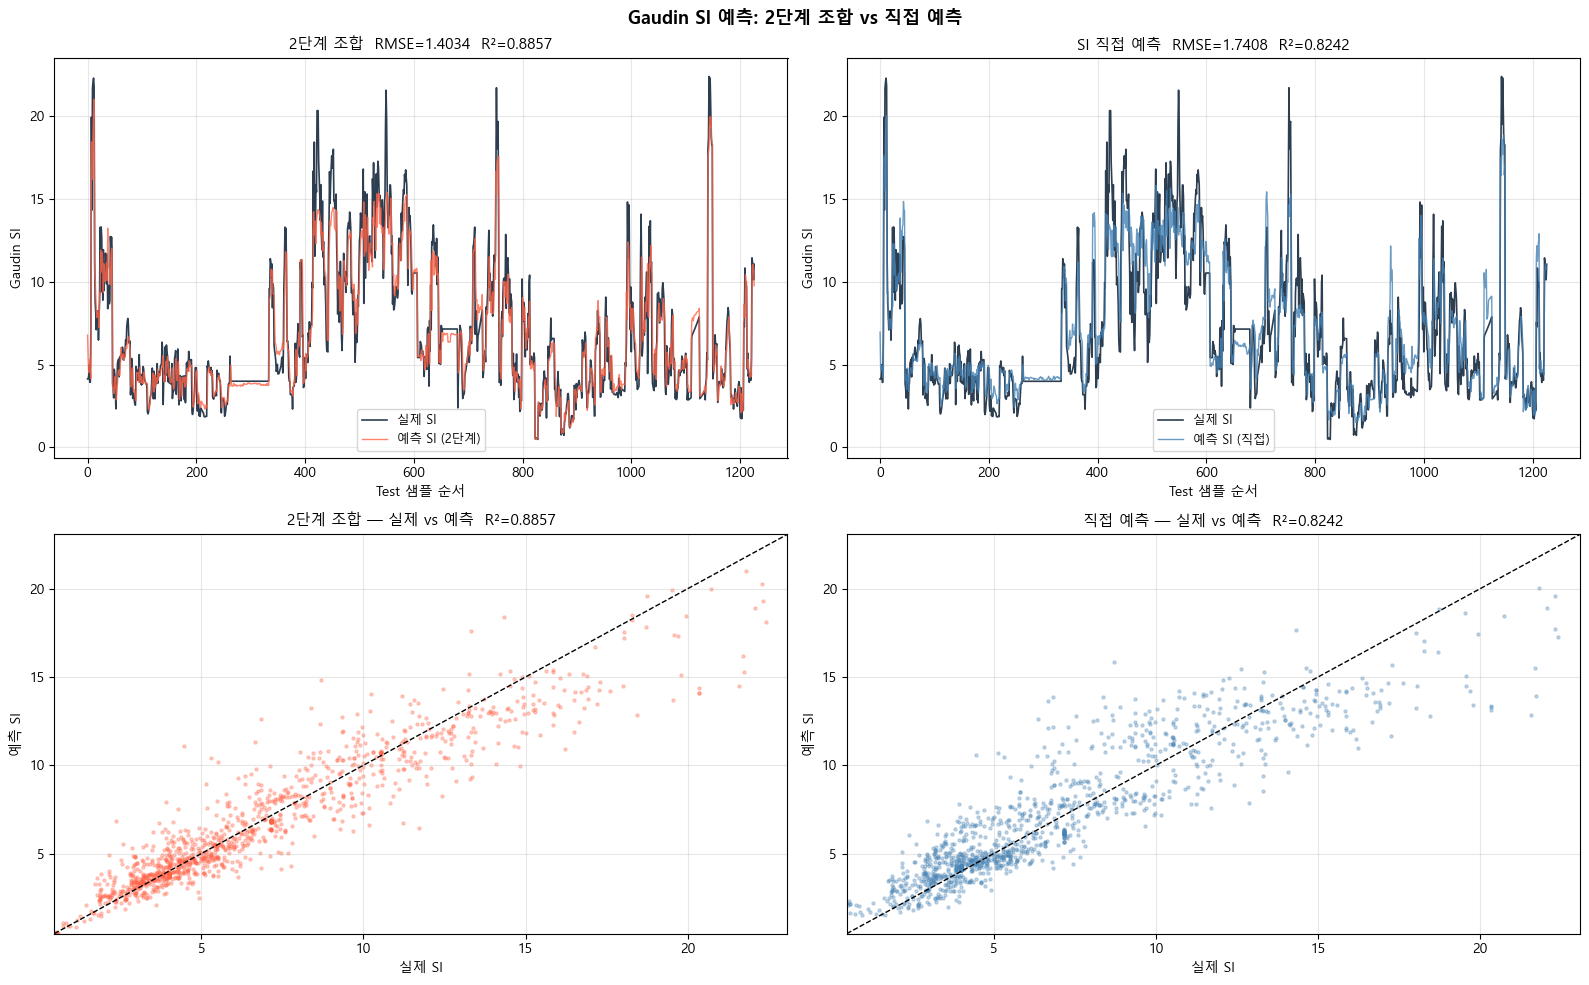

저장: gaudin_SI_comparison.png


In [9]:
# ── Step 7. 최종 비교표 + 시각화 ─────────────────────────────────────────────
impr = (direct_rmse - si_rmse) / direct_rmse * 100

print("=" * 55)
print(f"  {'방법':<28s}  {'RMSE':>8}  {'R²':>8}")
print("-" * 55)
print(f"  {'2단계 조합 (Fe + Si → SI)':<28s}  {si_rmse:>8.4f}  {si_r2:>8.4f}")
print(f"  {'SI 직접 예측':<28s}  {direct_rmse:>8.4f}  {direct_r2:>8.4f}")
print("=" * 55)
print(f"  2단계 조합 RMSE 개선: {impr:+.2f}%  (양수 = 2단계 조합 우수)")

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(len(act_SI))
mn, mx = act_SI.min() * 0.97, act_SI.max() * 1.03

# (1) 시계열: 2단계 조합
axes[0,0].plot(x, act_SI,  color="#2c3e50", lw=1.2, label="실제 SI")
axes[0,0].plot(x, pred_SI, color="tomato",  lw=1.0, alpha=0.8, label="예측 SI (2단계)")
axes[0,0].set_title(f"2단계 조합  RMSE={si_rmse:.4f}  R²={si_r2:.4f}", fontsize=11)
axes[0,0].set_xlabel("Test 샘플 순서"); axes[0,0].set_ylabel("Gaudin SI")
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

# (2) 시계열: 직접 예측
axes[0,1].plot(x, act_SI,          color="#2c3e50",  lw=1.2, label="실제 SI")
axes[0,1].plot(x, pred_SI_direct,  color="steelblue",lw=1.0, alpha=0.8, label="예측 SI (직접)")
axes[0,1].set_title(f"SI 직접 예측  RMSE={direct_rmse:.4f}  R²={direct_r2:.4f}", fontsize=11)
axes[0,1].set_xlabel("Test 샘플 순서"); axes[0,1].set_ylabel("Gaudin SI")
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

# (3) 산점도: 2단계 조합
axes[1,0].scatter(act_SI, pred_SI, alpha=0.3, s=5, color="tomato")
axes[1,0].plot([mn,mx],[mn,mx],"k--",lw=1)
axes[1,0].set_xlim(mn,mx); axes[1,0].set_ylim(mn,mx)
axes[1,0].set_title(f"2단계 조합 — 실제 vs 예측  R²={si_r2:.4f}", fontsize=11)
axes[1,0].set_xlabel("실제 SI"); axes[1,0].set_ylabel("예측 SI")
axes[1,0].grid(alpha=0.3)

# (4) 산점도: 직접 예측
axes[1,1].scatter(act_SI, pred_SI_direct, alpha=0.3, s=5, color="steelblue")
axes[1,1].plot([mn,mx],[mn,mx],"k--",lw=1)
axes[1,1].set_xlim(mn,mx); axes[1,1].set_ylim(mn,mx)
axes[1,1].set_title(f"직접 예측 — 실제 vs 예측  R²={direct_r2:.4f}", fontsize=11)
axes[1,1].set_xlabel("실제 SI"); axes[1,1].set_ylabel("예측 SI")
axes[1,1].grid(alpha=0.3)

plt.suptitle("Gaudin SI 예측: 2단계 조합 vs 직접 예측", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("gaudin_SI_comparison.png", bbox_inches="tight")
plt.show()
print("저장: gaudin_SI_comparison.png")

## Step 8. 상대 RMSE — RMSE > 1의 해석

### 핵심: RMSE와 R²는 측정하는 잣대가 다르다

**RMSE** = 예측이 실제값과 평균적으로 얼마나 떨어져 있나 → **SI 단위 (절대값)**

**R²** = 예측이 전체 변동을 얼마나 잘 따라가나 → **비율 (0~1, 단위 없음)**

---

### 쉬운 예시로 이해하기

> 키를 예측하는 모델이 있다고 하자.  
> - 한국 성인 키 평균 170cm, 표준편차 7cm  
> - 모델 RMSE = **3cm**  
> - R² = 1 - (3²/7²) = **0.82**  
>
> "RMSE 3cm"는 단위가 cm이기 때문에 크고 작음을 바로 판단할 수 있다.  
> 하지만 R²는 3cm가 전체 분산(7cm) 대비 얼마나 작은지를 비율로 나타낸 것.

---

### 이 데이터에 적용하면

실제 SI 값의 **평균 = 6.8, 표준편차 = 4.15** (범위가 넓다)

$$R^2 = 1 - \frac{RMSE^2}{\sigma^2} = 1 - \frac{1.75^2}{4.15^2} = 0.82$$

**RMSE 1.75가 크게 느껴지는 이유**: 숫자 1보다 커서  
**실제로는 괜찮은 이유**: SI 평균(6.8) 대비 **26% 오차** — 두 모델 오차가 합산된 파생 지표치고 납득 가능한 수준

> ※ R²는 수학적으로 1을 초과할 수 없다 (RMSE = 0일 때 R² = 1이 최대)

In [10]:
# ── Step 8. 상대 RMSE 계산 ────────────────────────────────────────────────────
si_mean = act_SI.mean()
si_std  = act_SI.std()

# 상대 RMSE (%) = RMSE / 평균 × 100
rel_rmse_2stage = si_rmse    / si_mean * 100
rel_rmse_direct = direct_rmse / si_mean * 100

# R² 검증: R² = 1 - RMSE² / σ²  (두 지표가 수치적으로 일치하는지 확인)
r2_verify_2stage = 1 - (si_rmse    ** 2) / (si_std ** 2)
r2_verify_direct = 1 - (direct_rmse ** 2) / (si_std ** 2)

print("=== 실제 SI 값 분포 ===")
print(f"  평균    : {si_mean:.4f}")
print(f"  표준편차: {si_std:.4f}")
print(f"  범위    : {act_SI.min():.4f} ~ {act_SI.max():.4f}")
print()
print("=" * 65)
print(f"  {'방법':<28s}  {'RMSE':>7}  {'상대 RMSE':>10}  {'R²':>7}")
print("-" * 65)
print(f"  {'2단계 조합 (Fe+Si→SI)':<28s}  {si_rmse:>7.4f}  {rel_rmse_2stage:>9.2f}%  {si_r2:>7.4f}")
print(f"  {'SI 직접 예측':<28s}  {direct_rmse:>7.4f}  {rel_rmse_direct:>9.2f}%  {direct_r2:>7.4f}")
print("=" * 65)
print()
print("=== R² = 1 - RMSE²/σ² 검증 ===")
print(f"  2단계 조합: 계산 R²={r2_verify_2stage:.4f}  실제 R²={si_r2:.4f}  → {'✓ 일치' if abs(r2_verify_2stage-si_r2)<0.001 else '✗ 불일치'}")
print(f"  직접 예측 : 계산 R²={r2_verify_direct:.4f}  실제 R²={direct_r2:.4f}  → {'✓ 일치' if abs(r2_verify_direct-direct_r2)<0.001 else '✗ 불일치'}")
print()
print(f"※ RMSE {si_rmse:.4f}는 SI 평균({si_mean:.2f}) 대비 {rel_rmse_2stage:.1f}% 오차")
print(f"※ SI 표준편차({si_std:.4f})가 크기 때문에 RMSE > 1이어도 R² = {si_r2:.4f} 가능")
print(f"※ R²는 항상 ≤ 1  (RMSE가 σ를 넘으면 R² < 0, 넘지 않으면 R² > 0)")

=== 실제 SI 값 분포 ===
  평균    : 6.8147
  표준편차: 4.1515
  범위    : 0.4781 ~ 22.4044

  방법                               RMSE     상대 RMSE       R²
-----------------------------------------------------------------
  2단계 조합 (Fe+Si→SI)              1.4034      20.59%   0.8857
  SI 직접 예측                       1.7408      25.55%   0.8242

=== R² = 1 - RMSE²/σ² 검증 ===
  2단계 조합: 계산 R²=0.8857  실제 R²=0.8857  → ✓ 일치
  직접 예측 : 계산 R²=0.8242  실제 R²=0.8242  → ✓ 일치

※ RMSE 1.4034는 SI 평균(6.81) 대비 20.6% 오차
※ SI 표준편차(4.1515)가 크기 때문에 RMSE > 1이어도 R² = 0.8857 가능
※ R²는 항상 ≤ 1  (RMSE가 σ를 넘으면 R² < 0, 넘지 않으면 R² > 0)


## Step 9. 최적 조업 조건 탐색

**목적**: 현재 공정 상태(feed 품질 + lag 고정)에서 조업 변수를 조절해 Gaudin SI를 최대화

**방법**: 학습된 XGBoost를 surrogate model로 사용 → `scipy.optimize.minimize`로 최적값 탐색

| 고정 입력 | 조절 대상 (9개) |
|---|---|
| P01 — % Iron Feed (광석 품질, 불가) | P03 — Starch Flow |
| P02 — % Silica Feed (광석 품질, 불가) | P04 — Amina Flow |
| Silica_lag1/2 (과거 측정값) | P05 — Ore Pulp Flow |
| Fe_lag1/2 (과거 측정값) | P06 — Ore Pulp pH |
| % Iron/Silica Feed | P07 — Ore Pulp Density |
| | RA — Rougher Air 평균 |
| | CA — Cleaner Air 평균 |
| | RL — Rougher Level 평균 |
| | CL — Cleaner Level 평균 |

> ⚠ **한계**: lag 피처가 예측을 지배하므로 조업 변수 단독 효과는 제한적  
> 민감도 분석으로 각 변수의 실제 SI 영향력을 함께 확인

=== 조절 변수 운영 범위 (5th ~ 95th percentile) ===
  P03: 1311.91 ~ 4388.16
  P04: 327.49 ~ 599.96
  P05: 381.76 ~ 409.75
  P06: 9.05 ~ 10.34
  P07: 1.53 ~ 1.76
  RA: 237.88 ~ 300.13
  CA: 273.44 ~ 323.86
  RL: 399.53 ~ 799.87
  CL: 348.62 ~ 548.41


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Us


=== 최적 조업 조건 탐색 결과 ===

  변수              현재          최적          변화
  ------------------------------------------
  P03        3707.06     3707.06       +0.00
  P04         530.69      530.69       +0.00
  P05         406.85      406.85       +0.00
  P06           9.80        9.80       +0.00
  P07           1.70        1.70       +0.00
  RA          299.43      299.43       +0.00
  CA          325.71      323.86       -1.86
  RL          500.10      500.10       +0.00
  CL          496.99      496.99       +0.00
  ------------------------------------------

  현재 예측 SI : 5.2460
  최적 예측 SI : 5.2460
  SI 개선량    : +0.0000
  SI 개선율    : +0.00%


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Us

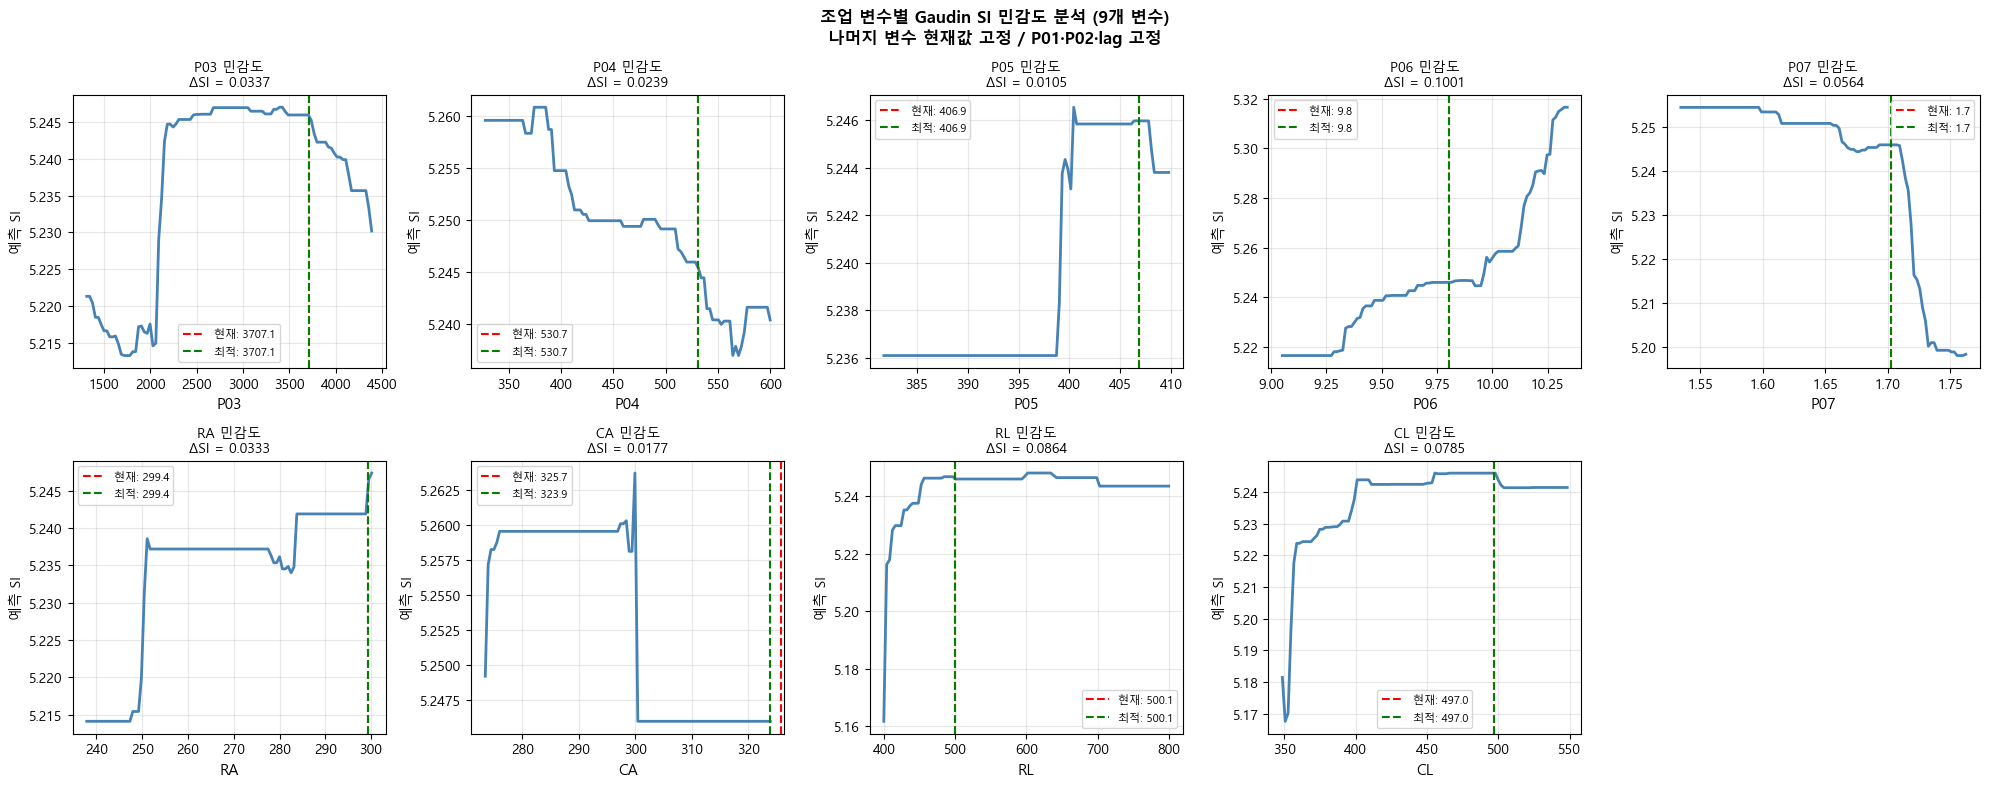

저장: sensitivity_SI.png

※ ΔSI가 작을수록 해당 변수의 SI 영향력이 낮음 (lag 지배적 공정의 한계)
※ 실제 운영에서는 lag가 주어진 상태에서 9개 조업 변수를 최적 설정점으로 조절


In [11]:
# ── Step 9. 최적 조업 조건 탐색 ───────────────────────────────────────────────
from scipy.optimize import minimize

# 조절 가능 변수: P01/P02는 광석 품질(불가), lag는 과거 측정값(고정)
# SI_FEAT_B = [P01,P02,P03,P04,P05,P06,P07, RA,CA,RL,CL, Silica_lag1,Silica_lag2]
# FE_FEAT_B = [P01,P02,P03,P04,P05,P06,P07, RA,CA,RL,CL, Fe_lag1,    Fe_lag2    ]
#  인덱스:       0   1   2   3   4   5   6   7  8  9 10       11          12

CTRL_VARS = ["P03", "P04", "P05", "P06", "P07", "RA", "CA", "RL", "CL"]
CTRL_IDX  = [2, 3, 4, 5, 6, 7, 8, 9, 10]   # 두 피처 배열에서 동일 위치

# 운영 범위: 훈련 데이터 5th ~ 95th percentile
ctrl_bounds = [
    (df_rsm_v[v].quantile(0.05), df_rsm_v[v].quantile(0.95))
    for v in CTRL_VARS
]
print("=== 조절 변수 운영 범위 (5th ~ 95th percentile) ===")
for v, (lo, hi) in zip(CTRL_VARS, ctrl_bounds):
    print(f"  {v}: {lo:.2f} ~ {hi:.2f}")

# ── 기준 시점: test set 중간 샘플 ────────────────────────────────────────────
sample_idx   = len(X_si_test) // 2
base_si_feat = X_si_test.iloc[sample_idx].values.astype(float)  # shape (13,)
base_fe_feat = X_fe_test.iloc[sample_idx].values.astype(float)  # shape (13,)
base_fe_feed = fe_feed_test[sample_idx]
base_si_feed = si_feed_test[sample_idx]

def predict_gaudin_si(ctrl):
    """ctrl = [P03, P04, P05, P06, P07, RA, CA, RL, CL] — P01/P02/lag는 고정"""
    feat_si = base_si_feat.copy()
    feat_fe = base_fe_feat.copy()
    for i, idx in enumerate(CTRL_IDX):
        feat_si[idx] = ctrl[i]
        feat_fe[idx] = ctrl[i]
    pred_si_log_v = model_si.predict([feat_si])[0]
    pred_fe_v     = model_fe.predict([feat_fe])[0]
    return (pred_fe_v * base_si_feed) / (np.exp(pred_si_log_v) * base_fe_feed)

# ── 최적화 (L-BFGS-B) ─────────────────────────────────────────────────────────
x0     = base_si_feat[CTRL_IDX].copy()   # 현재 조업 조건
result = minimize(
    lambda x: -predict_gaudin_si(x),
    x0=x0,
    method="L-BFGS-B",
    bounds=ctrl_bounds,
    options={"maxiter": 1000, "ftol": 1e-9},
)
si_current = predict_gaudin_si(x0)
si_optimal = predict_gaudin_si(result.x)

print("\n=== 최적 조업 조건 탐색 결과 ===")
print(f"\n  {'변수':<6}  {'현재':>10}  {'최적':>10}  {'변화':>10}")
print("  " + "-" * 42)
for v, cur, opt in zip(CTRL_VARS, x0, result.x):
    print(f"  {v:<6}  {cur:>10.2f}  {opt:>10.2f}  {opt-cur:>+10.2f}")
print("  " + "-" * 42)
print(f"\n  현재 예측 SI : {si_current:.4f}")
print(f"  최적 예측 SI : {si_optimal:.4f}")
print(f"  SI 개선량    : {si_optimal - si_current:>+.4f}")
print(f"  SI 개선율    : {(si_optimal - si_current) / si_current * 100:>+.2f}%")

# ── 민감도 분석: 변수별 SI 변화 시각화 ───────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (v, (lo, hi)) in enumerate(zip(CTRL_VARS, ctrl_bounds)):
    sweep   = np.linspace(lo, hi, 100)
    si_vals = []
    for val in sweep:
        ctrl    = x0.copy()
        ctrl[i] = val
        si_vals.append(predict_gaudin_si(ctrl))

    delta = max(si_vals) - min(si_vals)
    axes[i].plot(sweep, si_vals, color="steelblue", lw=2)
    axes[i].axvline(x0[i],       color="red",   ls="--", lw=1.5, label=f"현재: {x0[i]:.1f}")
    axes[i].axvline(result.x[i], color="green", ls="--", lw=1.5, label=f"최적: {result.x[i]:.1f}")
    axes[i].set_xlabel(v, fontsize=11)
    axes[i].set_ylabel("예측 SI", fontsize=10)
    axes[i].set_title(f"{v} 민감도\nΔSI = {delta:.4f}", fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# 마지막 빈 subplot 숨기기
axes[-1].set_visible(False)

plt.suptitle(
    "조업 변수별 Gaudin SI 민감도 분석 (9개 변수)\n"
    "나머지 변수 현재값 고정 / P01·P02·lag 고정",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig("sensitivity_SI.png", bbox_inches="tight")
plt.show()
print("저장: sensitivity_SI.png")
print()
print("※ ΔSI가 작을수록 해당 변수의 SI 영향력이 낮음 (lag 지배적 공정의 한계)")
print("※ 실제 운영에서는 lag가 주어진 상태에서 9개 조업 변수를 최적 설정점으로 조절")